# **1. Import Library**

In [ ]:
import pandas as df_lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import warnings
warnings.filterwarnings("ignore")
import random
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# **2. Memuat Dataset dari Hasil Clustering**

In [ ]:
df = pd.read_csv("data_clustering_inverse.csv")
print("Dataset loaded. Shape:", df.shape)
if 'Target' not in df.columns:
    raise KeyError("Kolom 'Target' tidak ditemukan di dataset. Pastikan file 'data_clustering_inverse.csv' berisi kolom Target.")
print("\nDistribusi label Target:")
print(df['Target'].value_counts())

Dataset loaded. Shape: (2514, 14)

Distribusi label Target:
Target
1    637
3    631
2    625
0    621
Name: count, dtype: int64


In [ ]:
df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,TransactionAmount_bin,CustomerAge_bin,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08,"(-1.021, -0.734]",young,2
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35,"(-0.294, 0.388]",young,2
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04,"(-0.734, -0.294]",NaN,3
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06,"(-0.734, -0.294]",NaN,2
4,13.45,2023-10-16 17:51:24,Debit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 8:06:39,"(-1.021, -0.734]",young,1


# **3. Data Splitting**

In [ ]:
X = df.drop(columns=['Target', 'TransactionAmount_bin', 'CustomerAge_bin'])
y = df['Target']

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

for col in categorical_cols:
    X[col] = X[col].astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)
print("Distribusi Target di training:")
print(y_train.value_counts(normalize=True).round(3))

Shapes -> X_train: (2011, 11) X_test: (503, 11)
Distribusi Target di training:
Target
1    0.253
3    0.251
2    0.249
0    0.247
Name: proportion, dtype: float64


# **4. Membangun Model Klasifikasi**

--- Decision Tree ---
Accuracy : 0.9960
Precision: 0.9961
Recall   : 0.9960
F1-score : 0.9960

Classification Report (Decision Tree):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       124
           1       1.00      1.00      1.00       128
           2       0.98      1.00      0.99       125
           3       1.00      0.98      0.99       126

    accuracy                           1.00       503
   macro avg       1.00      1.00      1.00       503
weighted avg       1.00      1.00      1.00       503



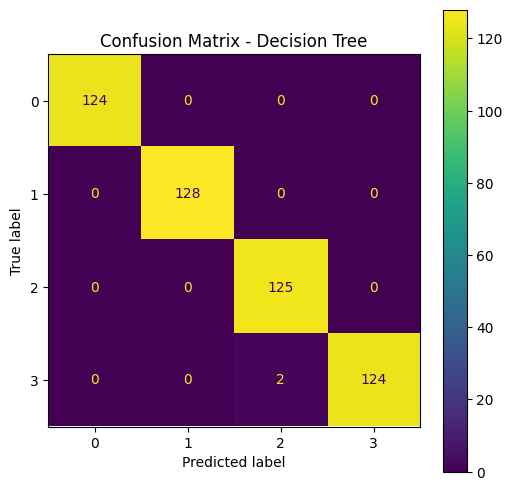

In [ ]:
model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

def print_metrics(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results = []
results.append(print_metrics("Decision Tree", y_test, y_pred_dt))
print("Classification Report (Decision Tree):\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [ ]:
joblib.dump(model_dt, "decision_tree_model.h5")
print("Decision Tree model saved to decision_tree_model.h5")

Decision Tree model saved to decision_tree_model.h5


# **5. Memenuhi Kriteria Skilled dan Advanced dalam Membangun Model Klasifikasi**



In [ ]:
models = {}

# Random Forest (does not strictly require scaling, but can sometimes benefit)
rf = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
rf.fit(X_train, y_train)
models['RandomForest'] = rf
results.append(print_metrics("Random Forest", y_test, rf.predict(X_test)))

# KNN (requires scaling)
knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
knn.fit(X_train, y_train)
models['KNN'] = knn
results.append(print_metrics("KNN", y_test, knn.predict(X_test)))

# Logistic Regression (scaling)
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
lr.fit(X_train, y_train)
models['LogisticRegression'] = lr
results.append(print_metrics("Logistic Regression", y_test, lr.predict(X_test)))

# SVM (scaling)
svm = Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=RANDOM_STATE))])
svm.fit(X_train, y_train)
models['SVM'] = svm
results.append(print_metrics("SVM", y_test, svm.predict(X_test)))

# Gaussian Naive Bayes (does not strictly require scaling, but can sometimes benefit)
gnb = Pipeline([('scaler', StandardScaler()), ('gnb', GaussianNB())])
gnb.fit(X_train, y_train)
models['GaussianNB'] = gnb
results.append(print_metrics("GaussianNB", y_test, gnb.predict(X_test)))

--- Random Forest ---
Accuracy : 0.9901
Precision: 0.9903
Recall   : 0.9901
F1-score : 0.9901

--- KNN ---
Accuracy : 0.6620
Precision: 0.6616
Recall   : 0.6620
F1-score : 0.6610

--- Logistic Regression ---
Accuracy : 0.9583
Precision: 0.9591
Recall   : 0.9583
F1-score : 0.9583

--- SVM ---
Accuracy : 0.8946
Precision: 0.9007
Recall   : 0.8946
F1-score : 0.8941

--- GaussianNB ---
Accuracy : 0.9543
Precision: 0.9558
Recall   : 0.9543
F1-score : 0.9542



,accuracy,precision,recall,f1
model,,,,
Decision Tree,0.996024,0.996086,0.996024,0.996024
Random Forest,0.990060,0.990263,0.990060,0.990060
Logistic Regression,0.958250,0.959065,0.958250,0.958256
GaussianNB,0.954274,0.955842,0.954274,0.954189
SVM,0.894632,0.900653,0.894632,0.894113
KNN,0.662028,0.661581,0.662028,0.660971


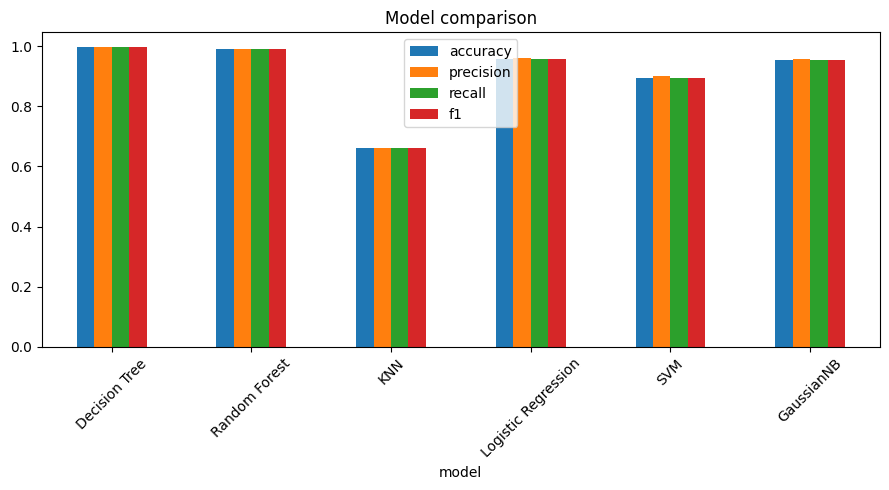

In [ ]:
results_df = pd.DataFrame(results).set_index('model')
display(results_df.sort_values(by='f1', ascending=False))

results_df[['accuracy','precision','recall','f1']].plot.bar(rot=45, figsize=(9,5), title="Model comparison")
plt.tight_layout()
plt.show()

In [ ]:
for name, m in models.items():
    fname = f"explore_{name.replace(' ','')}_classification.h5"
    joblib.dump(m, fname)
    print("Saved:", fname)

Saved: explore_RandomForest_classification.h5
Saved: explore_KNN_classification.h5
Saved: explore_LogisticRegression_classification.h5
Saved: explore_SVM_classification.h5
Saved: explore_GaussianNB_classification.h5


In [ ]:
pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

param_dist_knn = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

rsearch_knn = RandomizedSearchCV(
    estimator=pipe_knn,
    param_distributions=param_dist_knn,
    n_iter=30,
    scoring='f1_weighted',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rsearch_knn.fit(X_train, y_train)
best_knn = rsearch_knn.best_estimator_
print("Best KNN params:", rsearch_knn.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best KNN params: {'knn__weights': 'distance', 'knn__p': 1, 'knn__n_neighbors': 25}



Tuned KNN Evaluation:
Accuracy : 0.8290
Precision: 0.8297
Recall   : 0.8290
F1-score : 0.8282

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       124
           1       0.87      0.85      0.86       128
           2       0.81      0.76      0.79       125
           3       0.83      0.79      0.81       126

    accuracy                           0.83       503
   macro avg       0.83      0.83      0.83       503
weighted avg       0.83      0.83      0.83       503



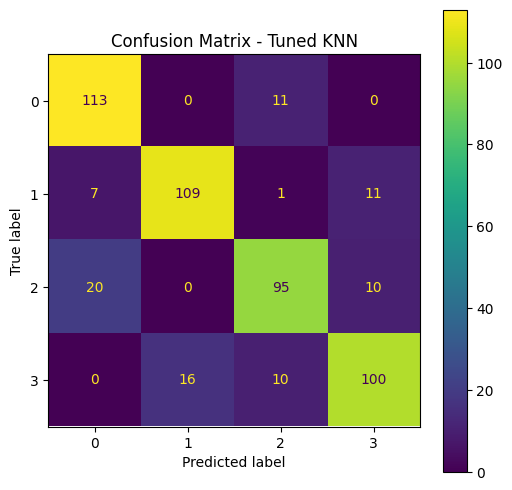

In [ ]:
y_pred = best_knn.predict(X_test)
print("\nTuned KNN Evaluation:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)
plt.title("Confusion Matrix - Tuned KNN")
plt.show()

In [ ]:
joblib.dump(best_knn, "tuning_classification.h5")
print("Tuned KNN model saved to tuning_classification.h5")

Tuned KNN model saved to tuning_classification.h5


End of Code